#### 13.4 Multiple Schemas

- Input State, Output State, Private State
- Private State : 노드 내부에서 사용될 상태값
- Input State : 사용자로부터 입력 받을 상태값
- Output State : 에이전트가 출력할 상태값

Note: `MegaPrivate`을 통해 `graph_builder`를 초기화할 때, 필드값으로 넘기지 않은
데이터 타입도 노드에서 State로 접근이 가능함을 볼 수 있다.

In [16]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

In [17]:
class PrivateState(TypedDict): 
    a: int
    b: int

class InputState(TypedDict):
    hello: str

class OutputState(TypedDict):
    bye: str

class MegaPrivate(TypedDict):
    secret: bool


graph_builder = StateGraph(
    state_schema=PrivateState, 
    input_schema=InputState,
    output_schema=OutputState,
)

In [ ]:
def node_one(state: InputState) -> InputState:
    print("node_one:", state)
    return {
        "hello": "world"
    }

def node_two(state: PrivateState) -> PrivateState:
    print("node_two:", state)
    return {
        "a": 1,
    }

def node_three(state: PrivateState) -> PrivateState:
    print("node_three:", state)
    return {
        "b": 1,
    }

def node_four(state: PrivateState) -> OutputState:
    print("node_four:", state)
    return {
        "bye": "world"
    }

def node_five(state: OutputState):
    return { "secret": True }

def node_six(state: MegaPrivate):
    print(state)

In [19]:
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)
graph_builder.add_node("node_three", node_three)
graph_builder.add_node("node_four", node_four)
graph_builder.add_node("node_five", node_five)
graph_builder.add_node("node_six", node_six)

graph_builder.add_edge(START, "node_one")
graph_builder.add_edge("node_one", "node_two")
graph_builder.add_edge("node_two", "node_three")
graph_builder.add_edge("node_three", "node_four")
graph_builder.add_edge("node_four", "node_five")
graph_builder.add_edge("node_five", "node_six")
graph_builder.add_edge("node_six", END)

In [ ]:
graph = graph_builder.compile()

result = graph.invoke({
    "hello": "world"
})

print(result) # 마지막 노드의 결과값이 아닌 OutputState 값이 나옴.

node_one: {'hello': 'world'}
node_two: {}
node_three: {'a': 1}
node_four: {'a': 1, 'b': 1}
{'secret': True}
{'bye': 'world'}


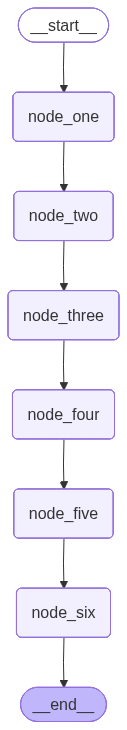

In [21]:
graph

# print(graph.get_graph().draw_ascii())